1. Feature Breakdown :
    * Glucose: Blood sugar level 2 hrs post-test. Normal: <140 mg/dL, Diabetes: ≥200 mg/dL. *(Note: `0` = missing data)*
    * Insulin: Hormone that clears glucose. High levels signal insulin resistance. *(Note: `0` = missing data)*
    * BMI: Weight to height ratio ($kg/m^2$). Obese: ≥30 (increases diabetes risk). *(Note: `0` = missing data)*
    * SkinThickness: Triceps skin fold (mm). Direct measure of body fat; strongly aligns with BMI. *(Note: `0` = missing data)*
    * Pregnancies: Total pregnancies. Hormonal shifts during pregnancy increase long-term risk.
    * Age: Risk multiplier as insulin sensitivity naturally drops over time.
    * DiabetesPedigreeFunction (DPF): Score measuring genetic risk based on family history.
    * BloodPressure: Diastolic pressure (mmHg). Co-occurs with metabolic syndrome.
    * Outcome: Target variable (`1` = Diabetes, `0` = No Diabetes).

2. Key Feature Relationships :
    * Glucose & Insulin: High Glucose + High Insulin = **Insulin Resistance**; High Glucose + Low Insulin = **Pancreatic Burnout**.
    * BMI & SkinThickness: Correlated metrics for body fat. Missing `SkinThickness` values can be imputed using `BMI`.
    * Pregnancies & Age: Older age naturally allows for more pregnancies; evaluate pregnancy counts relative to age.
    * Age + BMI + DPF: Combine baseline demographic, physical, and genetic risk multipliers to predict overall probability.

3. Phase - II ( find the best threshold value )

In [1]:
dataset_path = r'C:\Users\SUSHIL KUMAR SAHOO\Downloads\DATASETS\Kaggle\Diabetes_female\diabetes.csv'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

In [2]:
df = pd.read_csv(dataset_path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Fix the feature names :
df.columns = [re.sub(r'(?<=.)(?=[A-Z][a-z])|(?<=[a-z0-9])(?=[A-Z])', '_', i).lower() for i in df.columns]
df.columns

Index(['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin',
       'bmi', 'diabetes_pedigree_function', 'age', 'outcome'],
      dtype='object')

In [4]:
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pregnancies                 768 non-null    int64  
 1   glucose                     768 non-null    int64  
 2   blood_pressure              768 non-null    int64  
 3   skin_thickness              768 non-null    int64  
 4   insulin                     768 non-null    int64  
 5   bmi                         768 non-null    float64
 6   diabetes_pedigree_function  768 non-null    float64
 7   age                         768 non-null    int64  
 8   outcome                     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.isnull().sum()

pregnancies                   0
glucose                       0
blood_pressure                0
skin_thickness                0
insulin                       0
bmi                           0
diabetes_pedigree_function    0
age                           0
outcome                       0
dtype: int64

In [7]:
print("Description : Diabetese Datasets")
df.describe().T

Description : Diabetese Datasets


,count,mean,std,min,25%,50%,75%,max
pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
blood_pressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
skin_thickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
bmi,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
diabetes_pedigree_function,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [8]:
X = df.drop(columns=['outcome'])
X

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [9]:
y = df['outcome']

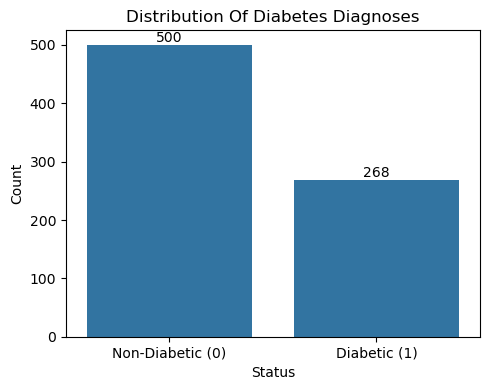

In [10]:
plt.figure(figsize=(5,4))
plt.title("Distribution Of Diabetes Diagnoses")
ax = sns.countplot(data=df,x='outcome')
ax.bar_label(ax.containers[0])
plt.xticks(ticks=[0, 1], labels=['Non-Diabetic (0)', 'Diabetic (1)'])
plt.xlabel("Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [11]:
zero_counts = (X==0).sum()
zero_counts

pregnancies                   111
glucose                         5
blood_pressure                 35
skin_thickness                227
insulin                       374
bmi                            11
diabetes_pedigree_function      0
age                             0
dtype: int64

* The zero values in several columns are invalid : 
    * Biologically impossible values : A living person can not have 0 glucose, blood pressure, skin thickness, insulin, or BMI.<br>
* Conclusion: These are hidden missing values (NaNs) that must be handled before training a model.

>### Assignment : Perform imputation on missing values  !

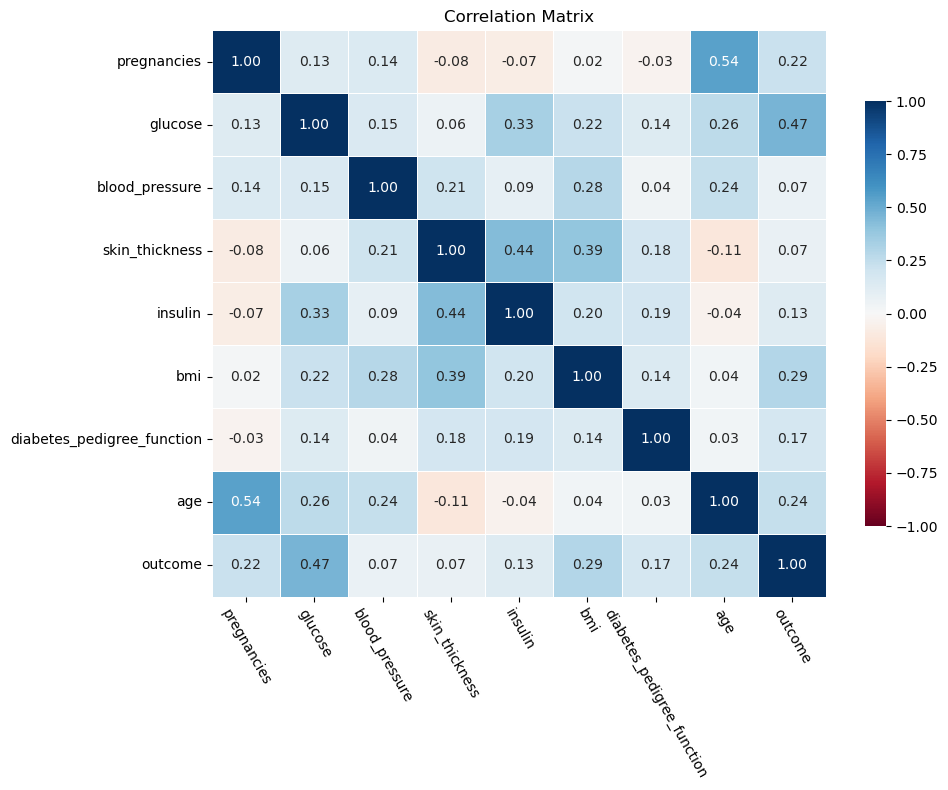

In [12]:
corr_ = df.corr()
plt.figure(figsize=(10,8))
plt.title("Correlation Matrix")
sns.heatmap(corr_,annot=True,cmap='RdBu',vmin=-1,vmax=1,center=0,linewidths=.5,fmt='.2f',cbar_kws={'shrink': .75})
plt.xticks(rotation=-60)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
import random

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=42,stratify=y)
print(f"After split\n   [ Train size : {X_train.shape}, Test size : {X_test.shape} ]")

After split
   [ Train size : (691, 8), Test size : (77, 8) ]


#Step 1 : Data imputation (handling missing values) :

In [15]:
columns_with_zeros = ['glucose','blood_pressure','skin_thickness','insulin','bmi']
zero_missing_cols = [c for c in columns_with_zeros if c in X_train.columns]
print(f"Columns with zeros (for treating 0 values as missing values) : {zero_missing_cols}")

Columns with zeros (for treating 0 values as missing values) : ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']


#Step 2 : Feature Scaling ( fixing range of data ) :

In [16]:
all_numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
# remaining_cols = [c for c in numeric_cols]
all_numeric_cols

['pregnancies',
 'glucose',
 'blood_pressure',
 'skin_thickness',
 'insulin',
 'bmi',
 'diabetes_pedigree_function',
 'age']

In [17]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.compose import ColumnTransformer

In [18]:
transformer = []
if zero_missing_cols:
    impute_scale = SklearnPipeline([
        ("impute_missing_zeros",SimpleImputer(missing_values=0,strategy='median')),
        ('scale_features',StandardScaler())
    ])
    transformer.append(("impute_scale",impute_scale,zero_missing_cols))
    # scaling of remaining columns which are not part of imputation
    remaining_cols_after_impute = [c for c in all_numeric_cols if c not in zero_missing_cols]
    # remaining_cols = [c for c in remaining_after_impute]
    if remaining_cols_after_impute:
        transformer.append(('scale_all_remained_cols',SklearnPipeline([('scale_remained',StandardScaler())]),remaining_cols_after_impute))
else:
     transformer.append(('scale_all_cols',SklearnPipeline([('scale_all',StandardScaler())]),all_numeric_cols))   

In [19]:
preprocessor = ColumnTransformer(transformers=transformer,remainder='drop') # if dataset has any columns and that are not listed in 
# transformer explicitly for imputation of missing or scaling these feature those are going to be dropped and there is another i.e passthrough that
# keeps those columns assuming them as cleaned and scaled

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
clf = LogisticRegression(solver='liblinear',max_iter=1000,random_state=42)

In [22]:
pipeline = SklearnPipeline([('preprocessing',preprocessor),('clf_model',clf)])

In [23]:
pipeline.fit(X_train,y_train)
print("Pipeline fitted to training data.")

Pipeline fitted to training data.


In [24]:
# Simplest Method without pipeline
# si = SimpleImputer(missing_values=0, strategy="median")
# ss = StandardScaler()
# clf = LogisticRegression(solver="liblinear", max_iter=1000, random_state=42)
# si = si.fit(X_train)
# X_train = si.transform(X_train)
# ss = ss.fit(X_train)
# X_train = ss.transform(X_train)
# clf.fit(X_train, y_train)
# y_train_pred = clf.predict(X_train)

In [25]:
# Predictions :  
y_train_predict = pipeline.predict(X_train)
y_test_predict = pipeline.predict(X_test)
# when sigmoid gives us the probability then this above prediction method gives us 0 anything below 0.5 else 1, means here bydefault 
# threshold = 0.5  

In [26]:
# To get only the prediction probabilty :
y_train_probas = pipeline.predict_proba(X_train)
y_test_probas = pipeline.predict_proba(X_test)
# print(y_test_probas) # this give the probabilty of both [[Probability('not happened' or 0 ),Probability('happened' or 1)]]
print(f"Probabilty Of Not Happened : \n{y_test_probas[:,0]}")
print('='*70)
print(f"Probabilty Of Happened : \n{y_test_probas[:,1]}") # probability of happened

Probabilty Of Not Happened : 
[0.95278626 0.31331183 0.24294861 0.66028572 0.88501954 0.64229456
 0.26960582 0.24562797 0.67947046 0.47655538 0.86698992 0.69823483
 0.8181897  0.97974983 0.89745624 0.07301725 0.9333887  0.14694041
 0.771333   0.93168762 0.92414941 0.87687593 0.96105498 0.8262423
 0.94795985 0.95019551 0.74079845 0.74945338 0.98780882 0.77312999
 0.39205068 0.30257741 0.67719742 0.84461214 0.00689909 0.98174775
 0.37899019 0.26207934 0.95646359 0.89920313 0.77726873 0.37738818
 0.21757087 0.8626184  0.95986119 0.25806223 0.71396469 0.13203589
 0.16114677 0.76981245 0.53258598 0.45971454 0.34360026 0.67554296
 0.65588035 0.05202015 0.30388924 0.92680816 0.67566997 0.90835296
 0.91460792 0.62094559 0.93326212 0.35293961 0.13495994 0.9478087
 0.35055855 0.55672861 0.4555568  0.32569909 0.94092903 0.66661062
 0.54870818 0.93554184 0.73883007 0.89547512 0.96455044]
Probabilty Of Happened : 
[0.04721374 0.68668817 0.75705139 0.33971428 0.11498046 0.35770544
 0.73039418 0.7543

In [27]:
# confidence = 0.9 or threshold 0.9
(y_test_probas[:,1] >= 0.33).astype(int)

array([0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0])

In [28]:
train_results = X_train.copy()
train_results['Actual'] = y_train.values
train_results['Predictions'] = y_train_predict
train_results["Probability"] = y_train_probas[:,1]
train_results.head(10)

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,Actual,Predictions,Probability
255,1,113,64,35,0,33.6,0.543,21,1,0,0.197638
125,1,88,30,42,99,55.0,0.496,26,1,1,0.512858
46,1,146,56,0,0,29.7,0.564,29,0,0,0.407504
312,2,155,74,17,96,26.6,0.433,27,1,0,0.371109
519,6,129,90,7,326,19.6,0.582,60,0,0,0.212198
738,2,99,60,17,160,36.6,0.453,21,0,0,0.172222
641,4,128,70,0,0,34.3,0.303,24,0,0,0.343457
96,2,92,62,28,0,31.6,0.130,24,0,0,0.072200
286,5,155,84,44,545,38.7,0.619,34,0,1,0.761192
420,1,119,88,41,170,45.3,0.507,26,0,0,0.438021


In [29]:
test_results = X_test.copy()
test_results['Actual'] = y_test.values
test_results['Predictions'] = y_test_predict
test_results["Probability"] = y_test_probas[:,1]
test_results.head(10)

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,Actual,Predictions,Probability
158,2,88,74,19,53,29.0,0.229,22,0,0,0.047214
484,0,145,0,0,0,44.2,0.630,31,1,1,0.686688
712,10,129,62,36,0,41.2,0.441,38,1,1,0.757051
535,4,132,0,0,0,32.9,0.302,23,1,0,0.339714
205,5,111,72,28,0,23.9,0.407,27,0,0,0.114980
531,0,107,76,0,0,45.3,0.686,24,0,0,0.357705
746,1,147,94,41,0,49.3,0.358,27,1,1,0.730394
440,0,189,104,25,0,34.3,0.435,41,1,1,0.754372
674,8,91,82,0,0,35.6,0.587,68,0,0,0.320530
517,7,125,86,0,0,37.6,0.304,51,0,1,0.523445


In [30]:
test_wrong_predictions = test_results[ test_results['Actual'] != test_results['Predictions'] ]
test_wrong_predictions.head(10)[['Actual', 'Predictions', 'Probability']]

,Actual,Predictions,Probability
535,1,0,0.339714
517,0,1,0.523445
17,1,0,0.181810
366,1,0,0.250547
44,0,1,0.607949
699,0,1,0.621010
558,0,1,0.622612
258,0,1,0.741938
264,1,0,0.286035
469,0,1,0.867964


In [31]:
test_wrong_predictions.shape

(21, 11)

In [53]:
test_results.groupby(['Actual','Predictions']).size()

Actual  Predictions
0       0              40
        1              10
1       0              11
        1              16
dtype: int64

In [33]:
# On the above see,
# when the actual is 0 but model predicted 1 = 11 ( wrong prediction count ) and
# when the actual is 1 but model predicted 0 = 10 ( wrong prediction count )
#                              total (11+10) = 21 our counting is correct then

In [34]:
from sklearn.metrics import (
                    accuracy_score,precision_score,recall_score,
                    roc_curve,f1_score,roc_auc_score,confusion_matrix,classification_report
) 

In [35]:
def compute_metrics(y_actual,y_pred):
    return {
      'accuracy' : accuracy_score(y_actual,y_pred),
      'precision' : precision_score(y_actual,y_pred,zero_division=0), 
      'recall' : recall_score(y_actual,y_pred,zero_division=0), 
      'f1_score' : f1_score(y_actual,y_pred,zero_division=0), 
      'roc_auc_score' : roc_auc_score(y_actual,y_pred),
      'confusion_matrix' : confusion_matrix(y_actual,y_pred),  
      'classification_report' : classification_report(y_actual,y_pred,output_dict=True)
    }

In [36]:
metrics_train = compute_metrics(train_results['Actual'],train_results['Predictions'])
for key,val in metrics_train.items():
    if key not in ("confusion_matrix","classification_report"):
        print(f"{key} : {val:.4f}")
# here we should more focus on recall : because if a person is diabetic but our model predict not diabetic so we need to minimize false negative
# so our model accuracy can be improved 

accuracy : 0.7800
precision : 0.7380
recall : 0.5726
f1_score : 0.6449
roc_auc_score : 0.7319


In [37]:
metrics_test = compute_metrics(test_results['Actual'],test_results['Predictions'])
for key,val in metrics_test.items():
    if key not in ("confusion_matrix","classification_report"):
        print(f"{key} : {val:.4f}")

accuracy : 0.7273
precision : 0.6154
recall : 0.5926
f1_score : 0.6038
roc_auc_score : 0.6963


In [38]:
train_repo = pd.DataFrame(metrics_train["classification_report"]).T
train_repo.head(12)

,precision,recall,f1-score,support
0,0.795635,0.891111,0.840671,450.000000
1,0.737968,0.572614,0.644860,241.000000
accuracy,0.780029,0.780029,0.780029,0.780029
macro avg,0.766801,0.731863,0.742765,691.000000
weighted avg,0.775522,0.780029,0.772378,691.000000


In [39]:
test_repo = pd.DataFrame(metrics_test['classification_report']).T
test_repo.head(12)

,precision,recall,f1-score,support
0,0.784314,0.800000,0.792079,50.000000
1,0.615385,0.592593,0.603774,27.000000
accuracy,0.727273,0.727273,0.727273,0.727273
macro avg,0.699849,0.696296,0.697926,77.000000
weighted avg,0.725079,0.727273,0.726050,77.000000


In [40]:
metrics_test['confusion_matrix']

array([[40, 10],
       [11, 16]])

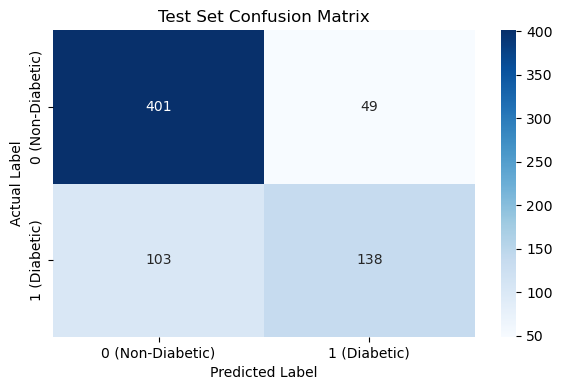

In [41]:
plt.figure(figsize=(6,4))
sns.heatmap(
    metrics_train['confusion_matrix'],
    cmap='Blues',
    fmt='d',
    annot=True,
    xticklabels=['0 (Non-Diabetic)', '1 (Diabetic)'],
    yticklabels=['0 (Non-Diabetic)', '1 (Diabetic)']
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

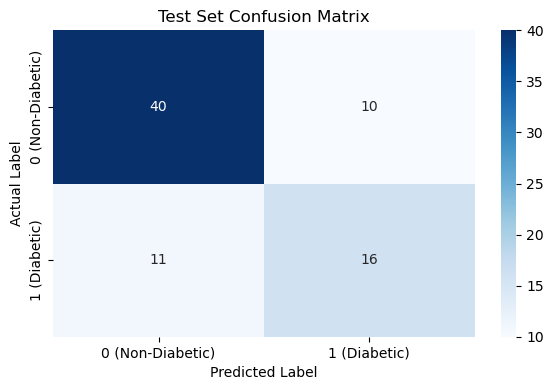

In [42]:
plt.figure(figsize=(6,4))
sns.heatmap(
    metrics_test['confusion_matrix'],
    cmap='Blues',
    fmt='d',
    annot=True,
    xticklabels=['0 (Non-Diabetic)', '1 (Diabetic)'],
    yticklabels=['0 (Non-Diabetic)', '1 (Diabetic)']
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

In [43]:
import joblib

output_path = 'logistic_regression_pipeline.pkl'
joblib.dump(pipeline,output_path)
print(f"\nSaved pipeline to {output_path}")


Saved pipeline to logistic_regression_pipeline.pkl


In [44]:
pipeline

,steps,"[('preprocessing', ...), ('clf_model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('impute_scale', ...), ('scale_all_remained_cols', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
pipeline['clf_model'].coef_.flatten()

array([ 1.11761071, -0.11117206,  0.00849131, -0.0013678 ,  0.64170799,
        0.40933862,  0.28269061,  0.13917814])

In [46]:
pipeline['clf_model'].intercept_

array([-0.84612488])

<h2 id='ii'> Phase 2 : </h2>
<li> ROC Curve</li> 
<li>  AUC Curve </li> 

In [47]:
# ROC Curve : 
fpr_train,tpr_train,thershold_train = roc_curve(y_train,y_train_predict)
fpr_test,tpr_test,thershold_test = roc_curve(y_test,y_test_predict)

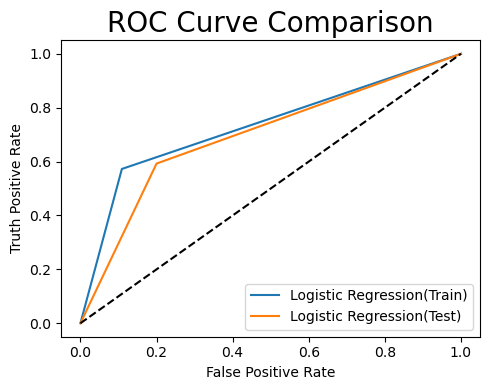

In [50]:
plt.figure(figsize=(5,4))
plt.title("ROC Curve Comparison",fontsize=20)
plt.plot(fpr_train,tpr_train,label="Logistic Regression(Train)")
plt.plot(fpr_test,tpr_test,label='Logistic Regression(Test)')
plt.plot([0,1],[0,1],'k--')
plt.ylabel("Truth Positive Rate")
plt.xlabel("False Positive Rate")
plt.tight_layout()
plt.legend(loc='lower right')
plt.show()


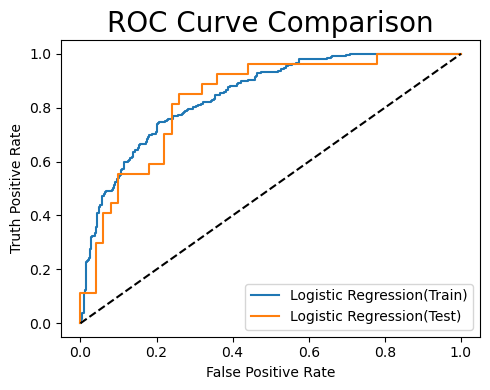

In [51]:
fpr_train_proba,tpr_train_proba,thershold_train_proba = roc_curve(y_train,y_train_probas[:,1])
fpr_test_proba,tpr_test_proba,thershold_test_proba = roc_curve(y_test,y_test_probas[:,1])

plt.figure(figsize=(5,4))
plt.title("ROC Curve Comparison",fontsize=20)
plt.plot(fpr_train_proba,tpr_train_proba,label="Logistic Regression(Train)")
plt.plot(fpr_test_proba,tpr_test_proba,label='Logistic Regression(Test)')
plt.plot([0,1],[0,1],'k--')
plt.ylabel("Truth Positive Rate")
plt.xlabel("False Positive Rate")
plt.tight_layout()
plt.legend()
plt.show()